In [1]:
# import required things
import numpy as np
import matplotlib as plt
from tensorflow.keras.datasets import mnist
from PIL import Image
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
#load Data
(train_image , train_label),(test_image ,test_label) = mnist.load_data()

In [3]:
len(train_label) ,len(train_image) ,len(test_image) , len(test_label)

(60000, 60000, 10000, 10000)

-----
#### For understanding


In [4]:
# Depth = 600000 , 2d images of 28 x 28 pixel

In [5]:
train_image[0].shape # 2 dimension gray scale image
                     # if it is -> (28,28,28) color image

(28, 28)

#### print images and its lables

In [6]:
Image.fromarray(train_image[0])

In [7]:
train_label[0]

np.uint8(5)

In [8]:
Image.fromarray(train_image[9])

In [9]:
train_label[9]

np.uint8(4)

-------

### Step 1 : Define model Structure

In [10]:
from tensorflow.keras import models , layers

In [11]:
model = models.Sequential()

In [12]:
model = models.Sequential([layers.Dense(512,activation='relu'),
                          layers.Dense(512,activation='softmax')])

In [13]:
# model.add(layers.Dense(512, activation='relu'))
# model.add(layers.Dense(512, activation='softmax'))

### Step 2: Compile Model : define loss function, optimizer , performance

In [14]:
model.compile(optimizer='rmsprop',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [15]:
#rmsprop -> it can optimize any kind of data 
#loss : since we have  multi class classification :[0,1,2,3,45,6,7,8,9,] so we use sparse categroical cross entropy
# if binary clss : binary cross entopy
# metric: performance metrics: accuracy , presion recall, f1_score

In [16]:
test_image.shape , train_image.shape

((10000, 28, 28), (60000, 28, 28))

In [17]:
# reshape the data (images) because
train_image = train_image.reshape(60000,28*28)
train_image = train_image.astype('float32')/255
test_image = test_image.reshape(10000,28*28)
test_image = test_image.astype('float32')/255

In [18]:
train_image[0] # now the image(matric) convert into the vector

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [19]:
model.fit(train_image,train_label,epochs=5,batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9079 - loss: 0.3425
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9613 - loss: 0.1323
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9745 - loss: 0.0874
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9812 - loss: 0.0639
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9854 - loss: 0.0490


In [20]:
60000/128 # time go for take the data


468.75

In [25]:
img_array = (test_image[9].reshape(28, 28) * 255).astype(np.uint8)
img_ = Image.fromarray(img_array, mode="L")
img_

In [27]:
test_predictions = model.predict(test_image)
predicted_class = np.argmax(test_predictions, axis=1)
# Get the index of the highest probability for the first image
predicted_class_8 = np.argmax(test_predictions[9])
print(f"Predicted Class: {predicted_class_8}")

# Get all predicted labels at once
all_predicted_labels = np.argmax(test_predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predicted Class: 9


In [28]:
print(classification_report(test_label, predicted_class))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.95      0.99      0.97      1010
           4       0.97      0.99      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.98      0.96      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



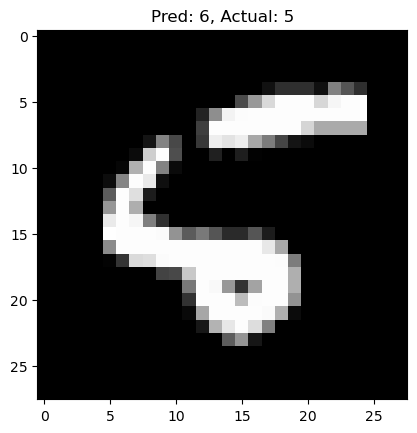

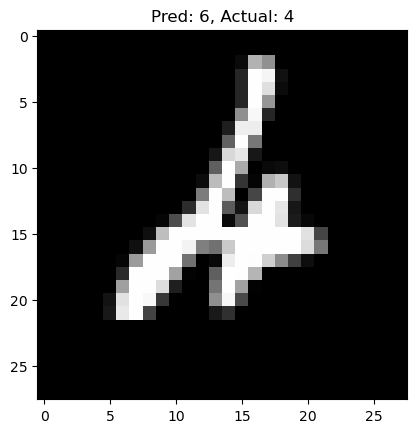

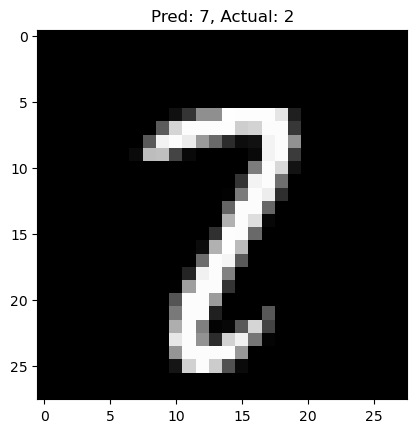

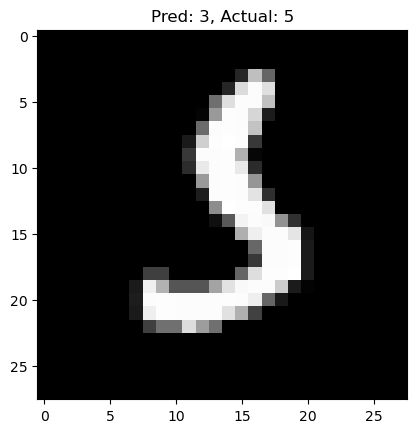

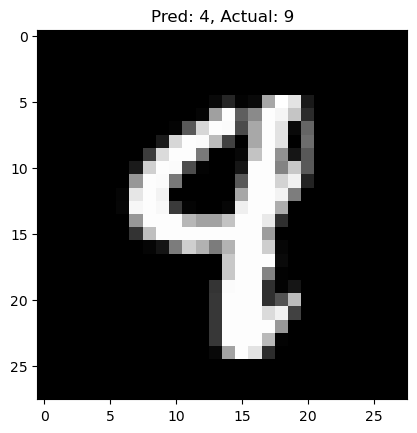

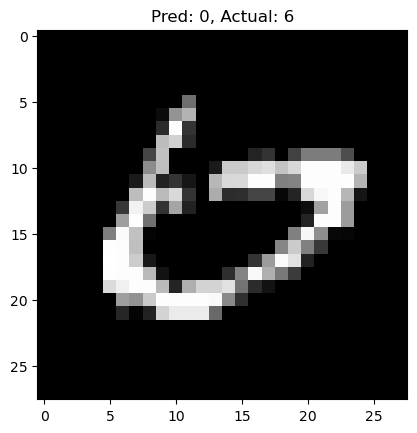

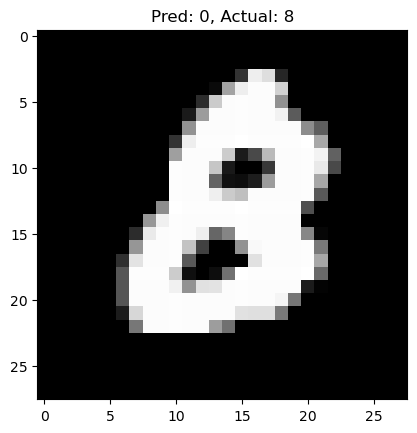

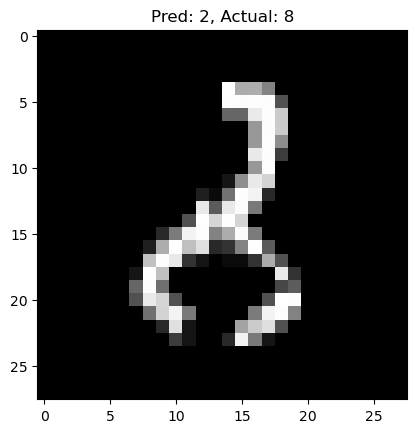

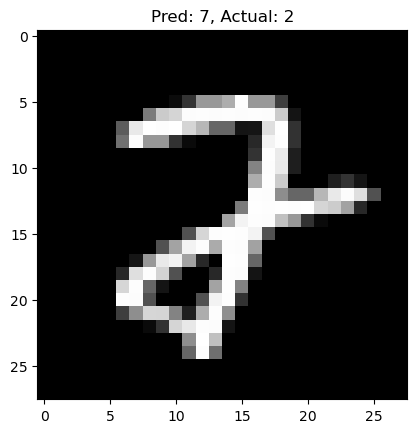

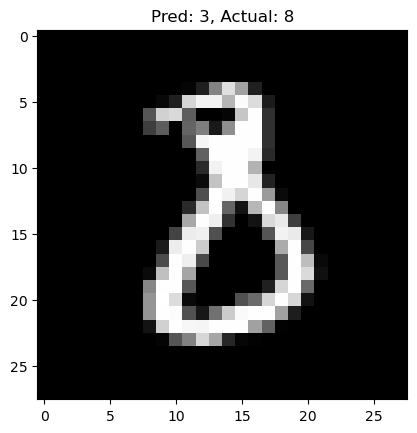

In [31]:
#model mistakes
misclassified = np.where(predicted_class != test_label)[0]

for i in misclassified[:10]:
    plt.imshow(test_image[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {predicted_class[i]}, Actual: {test_label[i]}")
    plt.show()

In [33]:
model.save('hand_written_digit_classifier.keras')